   Tenure  MonthlyCharges  DataUsage  SupportTickets  Churn
0      39       62.053578         42               2      0
1      52       98.466826          8               8      0
2      29       83.936136         24               3      0
3      15      100.504467         16               6      1
4      43      110.315106         49               8      1


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6266 - loss: 0.6636 - val_accuracy: 0.7250 - val_loss: 0.6182
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7406 - loss: 0.5893 - val_accuracy: 0.7750 - val_loss: 0.5475
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7719 - loss: 0.5308 - val_accuracy: 0.7812 - val_loss: 0.4965
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7797 - loss: 0.4867 - val_accuracy: 0.7812 - val_loss: 0.4621
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7906 - loss: 0.4527 - val_accuracy: 0.7875 - val_loss: 0.4367
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8094 - loss: 0.4258 - val_accuracy: 0.7875 - val_loss: 0.4152
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8125 - loss: 0.4033 - val_accuracy: 0.8125 - val_loss: 0.3962
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8234 - loss: 0.3826 - val_accuracy: 0.8313 - v

C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


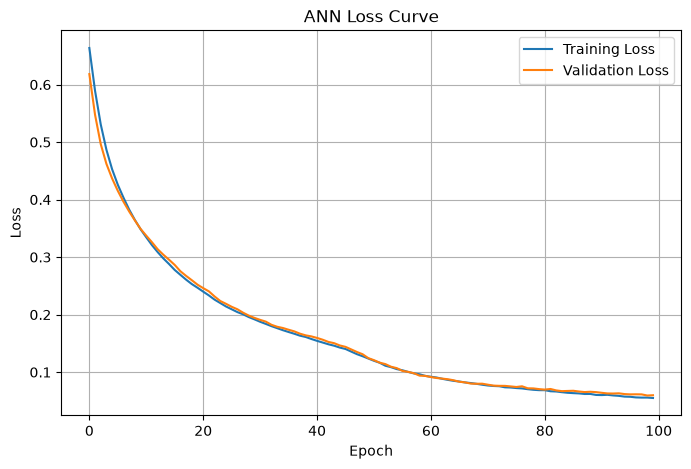

In [8]:
#Customer Churn Prediction using ANN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Input

#Step 1: CREATE DATASET

np.random.seed(42)
tenure=np.random.randint(1,60,1000)
monthly_charges=np.random.uniform(20,120,1000)
data_usage=np.random.randint(1,50,1000)
support_tickets=np.random.randint(0,10,1000)

#Churn rule
churn=((tenure<12) & (support_tickets>3))| (monthly_charges>100)
churn=churn.astype(int)

#Create Dataframe
df=pd.DataFrame({'Tenure':tenure,'MonthlyCharges':monthly_charges,'DataUsage':data_usage,'SupportTickets':support_tickets,'Churn':churn})
print(df.head())

#Step 2: Inputs and Output
X=df[['Tenure','MonthlyCharges','DataUsage','SupportTickets']]
y=df['Churn']

#Step 3:Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Step 4:Feature Scaling

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

#Step 5:Build ANN Model
model=Sequential([
    Input(shape=(4,)),
    Dense(16,activation='relu'),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

#Step 6:Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Step 7: Model Summary

model.summary()

#Step 8: Train Model

history=model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

#Step 9:Evaluate

loss,acc=model.evaluate(X_test,y_test)
print('Loss:',loss)
print('Accuracy:',acc)

#Step 10:Predict New Customer

new_customer=np.array([[10,110,20,5]])
new_customer_scaled=scaler.transform(new_customer)
prediction=model.predict(new_customer_scaled)
print('\nChurn Probability:',prediction[0][0])
print('Predicted Churn:','Yes'if prediction[0][0]>0.5 else 'No')

#Step 11:Visualize Training

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title('ANN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()
      
    

    

